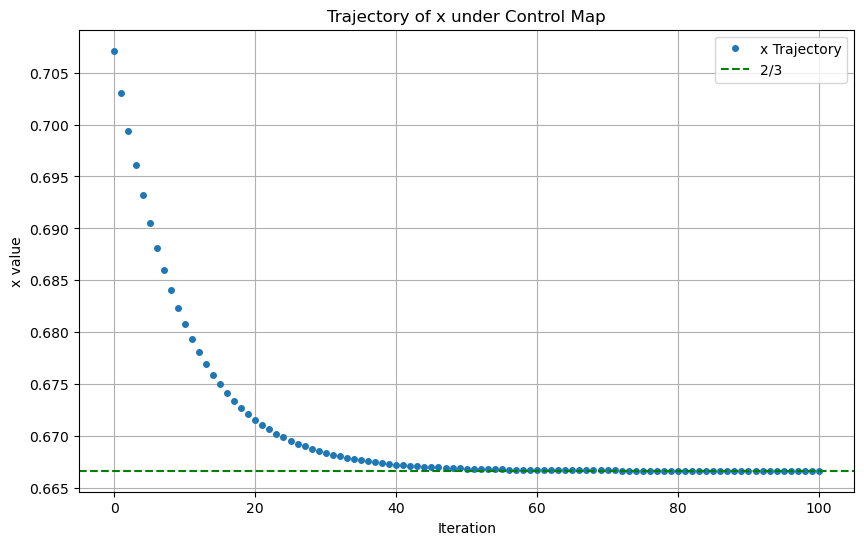

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def control_map(x, a, stable_orbit):
    closest_x_f = min(stable_orbit, key=lambda x_f: abs(x - x_f))
    return (1 - a) * closest_x_f + a * x

def simulate(x0, a, num_iterations, stable_orbit):
    trajectory = [x0]
    x = x0

    for _ in range(num_iterations):
        x = control_map(x, a, stable_orbit)
        trajectory.append(x)
    
    return trajectory

# Parameters
x0 = 1 / np.sqrt(2)
a = 0.9
num_iterations = 100
stable_orbit = [1/3, 2/3]

# Simulate the process
trajectory = simulate(x0, a, num_iterations, stable_orbit)

# Plot the trajectory
plt.figure(figsize=(10, 6))
plt.plot(trajectory, 'o', markersize=4, label='x Trajectory')
# plt.axhline(y=1/3, color='r', linestyle='--', label='1/3')
plt.axhline(y=2/3, color='g', linestyle='--', label='2/3')
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.title('Trajectory of x under Control Map')
plt.legend()
plt.grid(True)
plt.show()

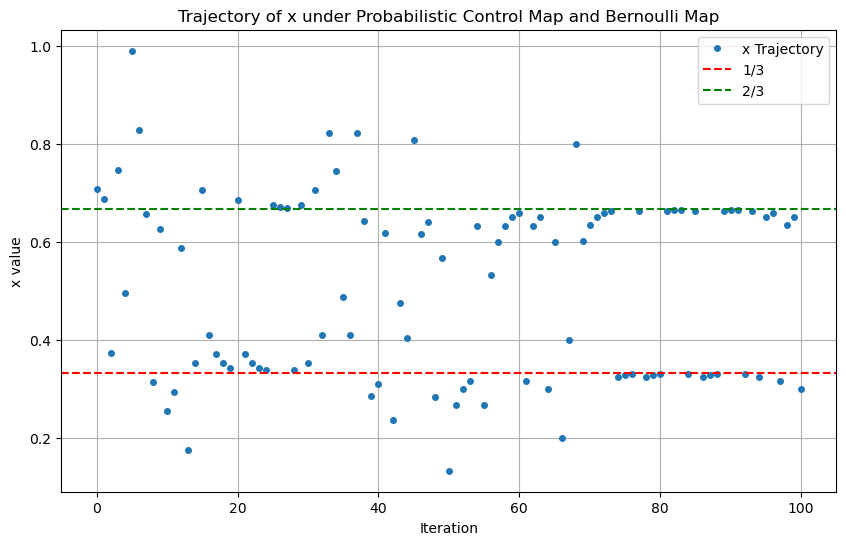

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def bernoulli_map(x):
    return (2 * x) % 1

def control_map(x, a, stable_orbit):
    closest_x_f = min(stable_orbit, key=lambda x_f: abs(x - x_f))
    return (1 - a) * closest_x_f + a * x

def simulate(x0, a, pm, num_iterations, stable_orbit):
    trajectory = [x0]
    x = x0

    for _ in range(num_iterations):
        if np.random.rand() < pm:
            x = control_map(x, a, stable_orbit)
        else:
            x = bernoulli_map(x)
        trajectory.append(x)
    
    return trajectory

# Parameters
x0 = 1 / np.sqrt(2)
a = 0.5
pm = 0.5  # Probability to apply control map
num_iterations = 100
stable_orbit = [1/3, 2/3]

# Simulate the process
trajectory = simulate(x0, a, pm, num_iterations, stable_orbit)

# Plot the trajectory
plt.figure(figsize=(10, 6))
plt.plot(trajectory, 'o', markersize=4, label='x Trajectory')
plt.axhline(y=1/3, color='r', linestyle='--', label='1/3')
plt.axhline(y=2/3, color='g', linestyle='--', label='2/3')
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.title('Trajectory of x under Probabilistic Control Map and Bernoulli Map')
plt.legend()
plt.grid(True)
plt.show()